# Bit-Copy Model Progression

This notebook walks through a bit-copy SDC system with successively more realistic model choices,
comparing `SDC1DBindReplace` stages and culminating in a comparison with the full `SDC` model.

**Stages:**
1. Pure glue-matching (defaults) — all rates = 1, uniform selection
2. Concentration-weighted selection — asymmetric strand concentrations
3. Energy-based replacement rates — `account_for_energy = True`
4. Physical attachment rates — `physical_attachment_rate = True`
5. Weak replacement — `allow_weak_replacement = True`
6. Bind/unbind replacement rates — `bindunbind_replacement_rate = True`
7. Full SDC model comparison
8. Completion time comparison at two temperatures

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from rgrow.sdc import SDCParams, SDCStrand, SDC
from rgrow.rgrow import SDC1DBindReplace
from rgrow import State, _system_plot_canvas

In [26]:
def mean_energies(strand_length: int = 10) -> tuple[float, float]:
    """Mean ΔG (kcal/mol) and ΔS (kcal/mol/K) for a domain of given length."""
    return (
        -1.405625 * (strand_length - 1),
        -0.02201875 * (strand_length - 1),
    )


def make_bitcopy_params(
    N: int,
    input_bit: str = "0",
    conc: float = 1e-7,
    conc0: float | None = None,
    conc1: float | None = None,
    cdl: int = 10,
    sdl: int = 20,
    include_energies: bool = False,
) -> SDCParams:
    """
    Build SDCParams for an N-site bit-copy cascade.

    Parameters
    ----------
    N : int
        Number of scaffold sites.
    input_bit : str
        '0' or '1' — which input strand is present.
    conc : float
        Default strand concentration.
    conc0, conc1 : float | None
        Override concentrations for bit-0 / bit-1 copy strands.
        If None, uses `conc`.
    cdl, sdl : int
        Cooperation and scaffold domain lengths (for energy calculation).
    include_energies : bool
        Whether to include glue_dg_s energy data.
    """
    strands = []

    if input_bit == "0":
        in0, in1 = 1e-7, 0.0
    else:
        in0, in1 = 0.0, 1e-7

    strands.append(SDCStrand(in0, "c0", "sc0", "c0*", "input0", color="blue"))
    strands.append(SDCStrand(in1, "c1", "sc0", "c1*", "input1", color="red"))

    c0 = conc0 if conc0 is not None else conc
    c1 = conc1 if conc1 is not None else conc

    for i in range(1, N):
        strands.append(SDCStrand(c0, "c0", f"sc{i}", "c0*", f"{i}_0", color="teal"))
        strands.append(SDCStrand(c1, "c1", f"sc{i}", "c1*", f"{i}_1", color="orange"))

    glue_dg_s = {}
    if include_energies:
        glue_dg_s = (
            {"c0": mean_energies(cdl)}
            | {"c1": mean_energies(cdl)}
            | {f"sc{i}": mean_energies(sdl) for i in range(N)}
        )

    return SDCParams(
        strands=strands,
        glue_dg_s=glue_dg_s,
        scaffold=[f"sc{i}*" for i in range(N)],
    )

In [27]:
N = 15
NUM_EVENTS = 200


def make_state(sys):
    state = State((1, N), kind="SquareCompact", tracking="None", n_tile_types=len(sys.tile_names))
    sys.update_state(state)
    return state


def show_canvas(sys, state, title=""):
    fig, ax = plt.subplots(figsize=(N, 1.5))
    _system_plot_canvas(sys, state, ax=ax, annotate_tiles=True, crop=True)
    ax.set_title(title)
    plt.show()

---
## Stage 1: Pure Glue-Matching (Defaults)

All rates = 1, uniform selection among candidates.  
Every strand that glue-matches at a site is equally likely to attach or replace.

In [28]:
params1 = make_bitcopy_params(N, input_bit="0")
sys1 = SDC1DBindReplace(params1)
state1 = make_state(sys1)

print(f"account_for_energy = {sys1.account_for_energy}")
print(f"physical_attachment_rate = {sys1.physical_attachment_rate}")
print(f"Tile names: {sys1.tile_names}")

account_for_energy = False
physical_attachment_rate = False
Tile names: ['empty', 'input0', 'input1', '1_0', '1_1', '2_0', '2_1', '3_0', '3_1', '4_0', '4_1', '5_0', '5_1', '6_0', '6_1', '7_0', '7_1', '8_0', '8_1', '9_0', '9_1', '10_0', '10_1', '11_0', '11_1', '12_0', '12_1', '13_0', '13_1', '14_0', '14_1']


Events: 200, Tiles: 15
Canvas: [[ 1  3  5  7  9 11 13 15 18 20 22 24 26 28 30]]


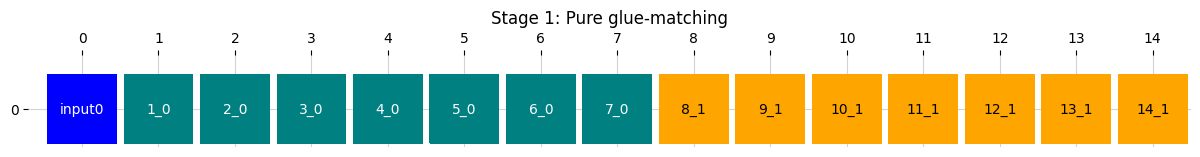

In [29]:
sys1.evolve(state1, for_events=NUM_EVENTS)
print(f"Events: {state1.total_events}, Tiles: {state1.ntiles}")
print(f"Canvas: {state1.canvas_view}")
show_canvas(sys1, state1, "Stage 1: Pure glue-matching")

In [30]:
# Rate array — all occupied sites with a valid replacer have rate 1.0,
# all empty sites with matching strands have rate 1.0.
rates1 = state1.rate_array()
print("Rate array (Stage 1):")
print(rates1)

Rate array (Stage 1):
[[0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.]]


---
## Stage 2: Concentration-Weighted Selection

Same system but with asymmetric strand concentrations:  
bit-0 strands at 1e-6 M, bit-1 strands at 1e-7 M.  
Selection among candidates is still proportional to concentration, but the overall site rate stays at 1.0 (no `physical_attachment_rate`).

Events: 156, Tiles: 15
Canvas: [[ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29]]


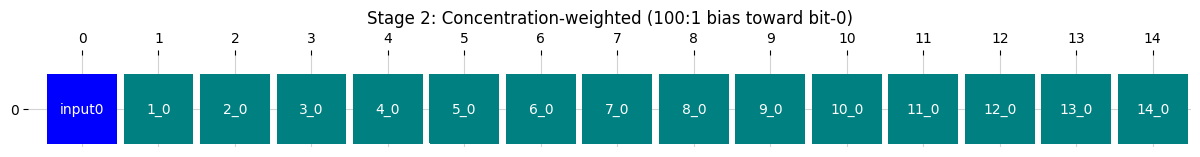

In [31]:
params2 = make_bitcopy_params(N, input_bit="0", conc0=1e-6, conc1=1e-7)
sys2 = SDC1DBindReplace(params2)
state2 = make_state(sys2)

sys2.evolve(state2, for_events=NUM_EVENTS)
print(f"Events: {state2.total_events}, Tiles: {state2.ntiles}")
print(f"Canvas: {state2.canvas_view}")
show_canvas(sys2, state2, "Stage 2: Concentration-weighted (100:1 bias toward bit-0)")

Events: 109, Tiles: 15
Canvas: [[ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29]]


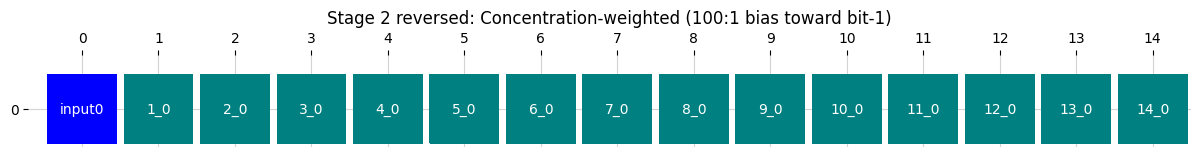

In [32]:
params2_r = make_bitcopy_params(N, input_bit="0", conc0=1e-7, conc1=1e-6)
sys2_r = SDC1DBindReplace(params2_r)
state2_r = make_state(sys2_r)

sys2_r.evolve(state2_r, for_events=NUM_EVENTS)
print(f"Events: {state2_r.total_events}, Tiles: {state2_r.ntiles}")
print(f"Canvas: {state2_r.canvas_view}")
show_canvas(sys2_r, state2_r, "Stage 2 reversed: Concentration-weighted (100:1 bias toward bit-1)")

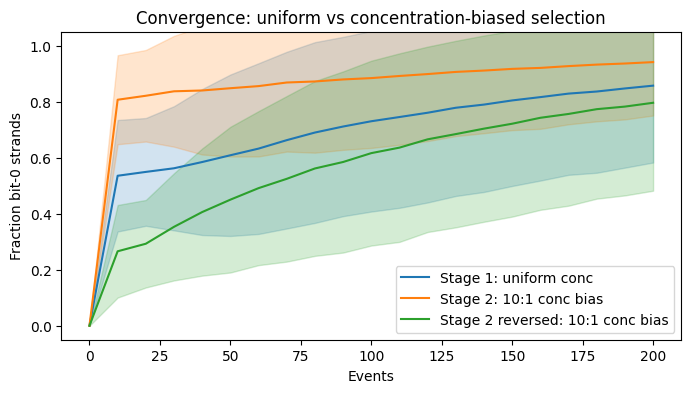

In [33]:
# Compare convergence: run many trials and measure fraction of bit-0 at the output site.
n_trials = 2000
event_steps = np.arange(0, NUM_EVENTS + 1, 10)

def measure_convergence(sys, params, event_steps, n_trials):
    frac_0 = np.zeros((n_trials, len(event_steps)))
    for trial in range(n_trials):
        st = make_state(sys)
        for j, target_events in enumerate(event_steps):
            if target_events > 0:
                remaining = target_events - st.total_events
                if remaining > 0:
                    sys.evolve(st, for_events=remaining)
            cv = np.array(st.canvas_view).flatten()
            # Count bit-0 strands (odd tile numbers > 0 in our naming: input0 is tile 1, {i}_0 tiles)
            # Tile numbering: 0=empty, 1=input0, 2=input1, 3=1_0, 4=1_1, 5=2_0, ...
            n_filled = np.sum(cv > 0)
            n_bit0 = np.sum((cv > 0) & (cv % 2 == 1))
            frac_0[trial, j] = n_bit0 / max(n_filled, 1)
    return frac_0

frac1 = measure_convergence(sys1, params1, event_steps, n_trials)
frac2 = measure_convergence(sys2, params2, event_steps, n_trials)
frac3 = measure_convergence(sys2_r, params2_r, event_steps, n_trials)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(event_steps, frac1.mean(axis=0), label="Stage 1: uniform conc", color="C0")
ax.fill_between(event_steps, frac1.mean(0) - frac1.std(0), frac1.mean(0) + frac1.std(0), alpha=0.2, color="C0")
ax.plot(event_steps, frac2.mean(axis=0), label="Stage 2: 10:1 conc bias", color="C1")
ax.fill_between(event_steps, frac2.mean(0) - frac2.std(0), frac2.mean(0) + frac2.std(0), alpha=0.2, color="C1")
ax.plot(event_steps, frac3.mean(axis=0), label="Stage 2 reversed: 10:1 conc bias", color="C2")
ax.fill_between(event_steps, frac3.mean(0) - frac3.std(0), frac3.mean(0) + frac3.std(0), alpha=0.2, color="C2")
ax.set_xlabel("Events")
ax.set_ylabel("Fraction bit-0 strands")
ax.set_title("Convergence: uniform vs concentration-biased selection")
ax.legend()
ax.set_ylim(-0.05, 1.05)
plt.show()

---
## Stage 3: Energy-Based Replacement Rates

Enable `account_for_energy = True` and provide `glue_dg_s` energy data.  
Now replacement rates depend on how strongly the current strand is bound —  
weakly-bound (mismatched) strands are replaced faster.

In [34]:
params3 = make_bitcopy_params(N, input_bit="0", include_energies=True)
sys3 = SDC1DBindReplace(params3)
sys3.account_for_energy = True
state3 = make_state(sys3)

print(f"account_for_energy = {sys3.account_for_energy}")
print(f"physical_attachment_rate = {sys3.physical_attachment_rate}")

account_for_energy = True
physical_attachment_rate = False


Events: 134, Tiles: 15
Canvas: [[ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29]]


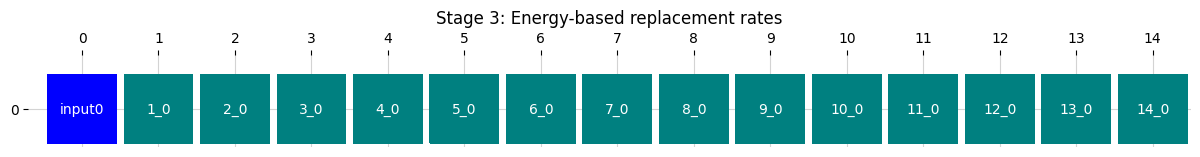

In [35]:
sys3.evolve(state3, for_events=NUM_EVENTS)
print(f"Events: {state3.total_events}, Tiles: {state3.ntiles}")
print(f"Canvas: {state3.canvas_view}")
show_canvas(sys3, state3, "Stage 3: Energy-based replacement rates")

In [36]:
# Compare rate arrays between stages 1 and 3.
# First, put both in the same configuration for a fair comparison.
compare_state1 = make_state(sys1)
compare_state3 = make_state(sys3)

# Evolve just enough to fill the scaffold
sys1.evolve(compare_state1, for_events=N * 2)
# Copy the same canvas config to state3
compare_state3_arr = compare_state3.canvas_view
compare_state1_arr = compare_state1.canvas_view
for j in range(compare_state1_arr.shape[1]):
    if compare_state1_arr[0, j] > 0:
        compare_state3_arr[0, j] = compare_state1_arr[0, j]
sys3.update_state(compare_state3)

rates1_cmp = compare_state1.rate_array()
rates3_cmp = compare_state3.rate_array()

print("Rate array (Stage 1 — uniform):")
print(rates1_cmp)
print("\nRate array (Stage 3 — energy-based):")
print(rates3_cmp)
print("\nRatio (Stage 3 / Stage 1) where nonzero:")
with np.errstate(divide='ignore', invalid='ignore'):
    ratio = np.where(rates1_cmp > 0, rates3_cmp / rates1_cmp, 0.0)
print(ratio)

Rate array (Stage 1 — uniform):
[[0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 1.]]

Rate array (Stage 3 — energy-based):
[[0.         0.01121326 0.01121326 0.01121326 0.         0.
  0.         0.         0.01121326 0.01121326 0.         0.
  0.01121326 4.02879476 1.        ]]

Ratio (Stage 3 / Stage 1) where nonzero:
[[0.         0.01121326 0.01121326 0.01121326 0.         0.
  0.         0.         0.01121326 0.01121326 0.         0.
  0.01121326 4.02879476 1.        ]]


---
## Stage 4: Physical Attachment Rates

Enable `physical_attachment_rate = True` so that the empty-site attachment rate  
is `sum(kf * conc)` over matching strands, rather than a flat 1.0.  


In [37]:
params4 = make_bitcopy_params(N, input_bit="0", include_energies=True)
sys4 = SDC1DBindReplace(params4)
sys4.account_for_energy = True
sys4.physical_attachment_rate = True
state4 = make_state(sys4)

print(f"account_for_energy = {sys4.account_for_energy}")
print(f"physical_attachment_rate = {sys4.physical_attachment_rate}")

account_for_energy = True
physical_attachment_rate = True


Events: 200, Tiles: 15
Canvas: [[ 1  4  6  8 10 12 14 16 18 20 22 24 26 28 30]]


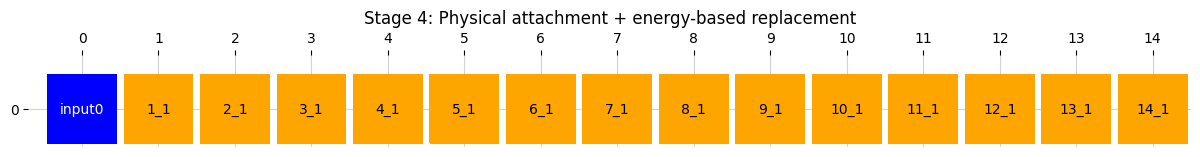

In [38]:
sys4.evolve(state4, for_events=NUM_EVENTS)
print(f"Events: {state4.total_events}, Tiles: {state4.ntiles}")
print(f"Canvas: {state4.canvas_view}")
show_canvas(sys4, state4, "Stage 4: Physical attachment + energy-based replacement")

In [39]:
# Compare rate arrays: Stage 3 (energy only) vs Stage 4 (energy + physical attachment)
compare_state3b = make_state(sys3)
compare_state4 = make_state(sys4)

# Rates on empty scaffolds
rates3_empty = compare_state3b.rate_array()
rates4_empty = compare_state4.rate_array()

total_conc = sum(s.concentration for s in params4.strands)

print("Rate array — empty scaffold, Stage 3 (energy, no physical att.):")
print(rates3_empty)
print("\nRate array — empty scaffold, Stage 4 (energy + physical att.):")
print(rates4_empty)
print(f"\nWith physical_attachment_rate, empty-site rate = kf * sum(concs) = {params4.k_f} * {total_conc:.2e}")

Rate array — empty scaffold, Stage 3 (energy, no physical att.):
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]

Rate array — empty scaffold, Stage 4 (energy + physical att.):
[[0.1 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]]

With physical_attachment_rate, empty-site rate = kf * sum(concs) = 1000000.0 * 2.90e-06


---
## Stage 5: Weak Replacement

Enable `allow_weak_replacement = True` so that any scaffold-matching strand can replace the
current occupant, even if it has fewer cooperation matches with the neighbors.

Without this option, a strand can only be replaced by one with equal or more cooperation
glue matches \u2014 meaning a correctly-cooperating strand is locked in.  With it enabled, the
replacement rate at a filled site equals the SDC detachment rate at that site, since any
alternative tile is a valid replacer.

In [40]:
params5 = make_bitcopy_params(N, input_bit="0", include_energies=True)
sys5wr = SDC1DBindReplace(params5)
sys5wr.account_for_energy = True
sys5wr.physical_attachment_rate = True
sys5wr.allow_weak_replacement = True
state5wr = make_state(sys5wr)

print(f"account_for_energy = {sys5wr.account_for_energy}")
print(f"physical_attachment_rate = {sys5wr.physical_attachment_rate}")
print(f"allow_weak_replacement = {sys5wr.allow_weak_replacement}")

account_for_energy = True
physical_attachment_rate = True
allow_weak_replacement = True


Events: 200, Tiles: 15
Canvas: [[ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 30]]


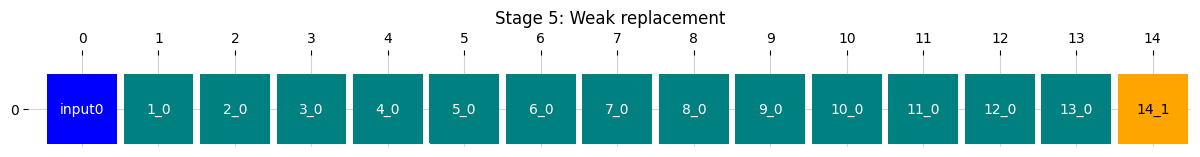

In [41]:
sys5wr.evolve(state5wr, for_events=NUM_EVENTS)
print(f"Events: {state5wr.total_events}, Tiles: {state5wr.ntiles}")
print(f"Canvas: {state5wr.canvas_view}")
show_canvas(sys5wr, state5wr, "Stage 5: Weak replacement")

In [42]:
# Compare rate arrays: Stage 4 (no weak replacement) vs Stage 5 (weak replacement)
# on the same filled configuration.
compare_state4b = make_state(sys4)
compare_state5wr = make_state(sys5wr)

# Fill both with the perfect bit-0 config
sys4.evolve(compare_state4b, for_events=N * 2)
canvas_arr = compare_state4b.canvas_view
for j in range(canvas_arr.shape[1]):
    if canvas_arr[0, j] > 0:
        compare_state5wr.canvas_view[0, j] = canvas_arr[0, j]
sys4.update_state(compare_state4b)
sys5wr.update_state(compare_state5wr)

rates4_filled = compare_state4b.rate_array()
rates5_filled = compare_state5wr.rate_array()

print("Rate array \u2014 filled scaffold, Stage 4 (no weak replacement):")
print(rates4_filled)
print("\nRate array \u2014 filled scaffold, Stage 5 (weak replacement):")
print(rates5_filled)
print("\nWith weak replacement, even correctly-cooperating strands can be replaced,")
print("so filled-site rates are nonzero everywhere (matching SDC detachment rates).")

Rate array — filled scaffold, Stage 4 (no weak replacement):
[[0.1        4.02879476 0.2        4.02879476 0.2        4.02879476
  0.2        4.02879476 0.2        0.         0.         0.2
  0.2        4.02879476 0.2       ]]

Rate array — filled scaffold, Stage 5 (weak replacement):
[[0.1        4.02879476 0.2        4.02879476 0.2        4.02879476
  0.2        4.02879476 0.2        0.01121326 0.01121326 0.2
  0.2        4.02879476 0.2       ]]

With weak replacement, even correctly-cooperating strands can be replaced,
so filled-site rates are nonzero everywhere (matching SDC detachment rates).


---
## Stage 6: Bind/Unbind Replacement Rates

Enable `bindunbind_replacement_rate = True` so that the replacement rate at a filled site
accounts for both the expected detachment time *and* the expected re-attachment time:

$$r_{\text{replace}} = \frac{1}{1/r_{\text{detach}} + 1/r_{\text{attach}}} = \frac{r_{\text{detach}} \cdot r_{\text{attach}}}{r_{\text{detach}} + r_{\text{attach}}}$$

Without this option (Stages 4–5), replacement is instantaneous once detachment occurs.
With it, the replacement rate is limited by whichever step is slower: detachment or
re-attachment.

In [ ]:
params6 = make_bitcopy_params(N, input_bit="0", include_energies=True)
sys6 = SDC1DBindReplace(params6)
sys6.account_for_energy = True
sys6.physical_attachment_rate = True
sys6.allow_weak_replacement = True
sys6.bindunbind_replacement_rate = True
state6 = make_state(sys6)

print(f"account_for_energy = {sys6.account_for_energy}")
print(f"physical_attachment_rate = {sys6.physical_attachment_rate}")
print(f"allow_weak_replacement = {sys6.allow_weak_replacement}")
print(f"bindunbind_replacement_rate = {sys6.bindunbind_replacement_rate}")

Events: 200, Tiles: 15
Canvas: [[ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29]]


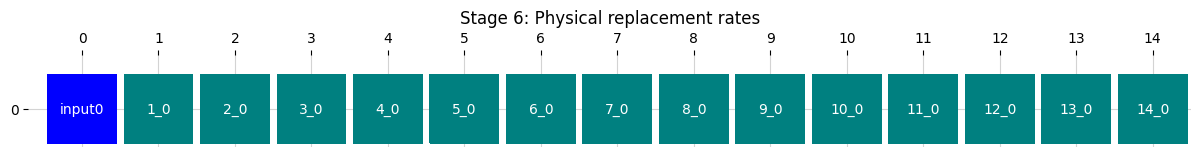

In [44]:
sys6.evolve(state6, for_events=NUM_EVENTS)
print(f"Events: {state6.total_events}, Tiles: {state6.ntiles}")
print(f"Canvas: {state6.canvas_view}")
show_canvas(sys6, state6, "Stage 6: Physical replacement rates")

In [45]:
# Compare rate arrays: Stage 5 (weak replacement, instant reattach)
# vs Stage 6 (weak replacement + physical replacement rate)
# on the same configuration with a single mismatch.
compare_state5b = make_state(sys5wr)
compare_state6 = make_state(sys6)

# Fill with all bit-0, then put a mismatch at position N//2
sys5wr.evolve(compare_state5b, for_events=N * 4)
canvas5 = compare_state5b.canvas_view
for j in range(canvas5.shape[1]):
    compare_state6.canvas_view[0, j] = canvas5[0, j]
sys5wr.update_state(compare_state5b)
sys6.update_state(compare_state6)

rates5b = compare_state5b.rate_array()
rates6b = compare_state6.rate_array()

print("Rate array \u2014 Stage 5 (detach-only replacement rate):")
print(rates5b)
print("\nRate array \u2014 Stage 6 (combined detach + attach replacement rate):")
print(rates6b)
print("\nThe combined rate is always \u2264 the detach-only rate.")
print("At well-bound sites (slow detach), the difference is negligible.")
print("At weakly-bound sites (fast detach), attachment becomes the bottleneck.")

Rate array — Stage 5 (detach-only replacement rate):
[[0.00000000e+00 3.12096169e-05 3.12096169e-05 3.12096169e-05
  3.12096169e-05 3.12096169e-05 3.12096169e-05 3.12096169e-05
  3.12096169e-05 1.12132574e-02 1.12132574e-02 1.12132574e-02
  1.12132574e-02 3.12096169e-05 1.12132574e-02]]

Rate array — Stage 6 (combined detach + attach replacement rate):
[[0.00000000e+00 3.11998795e-05 3.11998795e-05 3.11998795e-05
  3.11998795e-05 3.11998795e-05 3.11998795e-05 3.11998795e-05
  3.11998795e-05 1.00826625e-02 1.00826625e-02 1.00826625e-02
  1.00826625e-02 3.11998795e-05 1.00826625e-02]]

The combined rate is always ≤ the detach-only rate.
At well-bound sites (slow detach), the difference is negligible.
At weakly-bound sites (fast detach), attachment becomes the bottleneck.


---
## Stage 7: Full SDC Model Comparison

Build an equivalent system using the full `SDC` model, which includes:  
- Scaffold concentration and detachment
- Equilibrium properties: `mfe_config`, `log_partition_function`
- Detailed energy bookkeeping

This shows what extra physics the full model captures beyond bind-replace.

In [46]:
params5 = make_bitcopy_params(N, input_bit="0", include_energies=True)
sys5 = SDC(params5)
sys5.temperature = 50  # Lower temperature so strands can bind in the full model

print(f"Tile names: {sys5.tile_names}")
print(f"Temperature: {sys5.temperature}°C")

Tile names: ['null', 'input0', 'input1', '1_0', '1_1', '2_0', '2_1', '3_0', '3_1', '4_0', '4_1', '5_0', '5_1', '6_0', '6_1', '7_0', '7_1', '8_0', '8_1', '9_0', '9_1', '10_0', '10_1', '11_0', '11_1', '12_0', '12_1', '13_0', '13_1', '14_0', '14_1', 'quencher', 'fluorophore']
Temperature: 50.0°C


In [47]:
# MFE configuration — the most stable arrangement of strands on the scaffold
mfe_tiles, mfe_energy = sys5.mfe_config()
mfe_names = [sys5.tile_names[t] for t in mfe_tiles]
print(f"MFE configuration: {mfe_names}")
print(f"MFE energy: {mfe_energy:.4f} (units of kT)")

MFE configuration: ['input0', '1_0', '2_0', '3_0', '4_0', '5_0', '6_0', '7_0', '8_0', '9_0', '10_0', '11_0', '12_0', '13_0', '14_0']
MFE energy: -304.8085 (units of kT)


In [48]:
# Partition function — sum over all possible configurations
log_Z = sys5.log_partition_function()
print(f"log(Z) = {log_Z:.4f}")

log(Z) = 474.6576


Full SDC — Events: 200000, Time: 2.4229e+13 s
Canvas: [[ 0  4  6  8  9 11 13 15 17 19 21 23 26 28 30]]


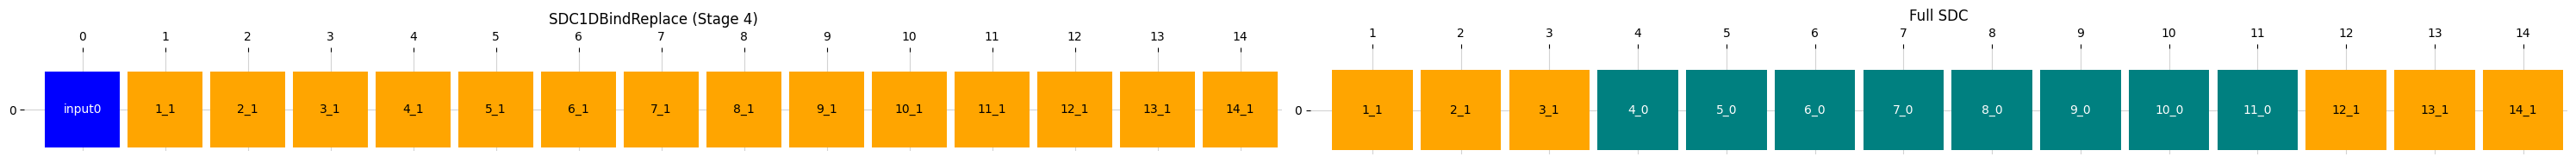

In [49]:
# Evolve the full SDC model and compare final state
state5 = State(
    (1, N), kind="SquareCompact", tracking="None",
    n_tile_types=len(sys5.tile_names),
)
sys5.update_all(state5)
sys5.evolve(state5, for_events=NUM_EVENTS * 1000)

print(f"Full SDC — Events: {state5.total_events}, Time: {state5.time:.4e} s")
print(f"Canvas: {state5.canvas_view}")

fig, axes = plt.subplots(1, 2, figsize=(2 * N, 1.8))
_system_plot_canvas(sys4, state4, ax=axes[0], annotate_tiles=True, crop=True)
axes[0].set_title("SDC1DBindReplace (Stage 4)")
if state5.ntiles > 0:
    _system_plot_canvas(sys5, state5, ax=axes[1], annotate_tiles=True, crop=True)
else:
    _system_plot_canvas(sys5, state5, ax=axes[1], annotate_tiles=True)
axes[1].set_title("Full SDC")
plt.tight_layout()
plt.show()

In [50]:
sys5.evolve(state5, show_window=True)

EvolveOutcome.ReachedZeroRate

---
## Stage 8: Completion Time Comparison

Compare five model configurations at two temperatures:

1. **BR (detach only)** — replacement rate = detachment rate; single-step
   replacement with `allow_weak_replacement = True`.
2. **BR (detach + attach)** — replacement rate is the harmonic mean of detachment
   and re-attachment rates (`bindunbind_replacement_rate = True`).
3. **BR (det + att + same)** — same as (2) but a tile can also be "replaced"
   by the same tile type (`allow_same_replacement = True`), wasting time on no-op
   cycles just as the full SDC model does.
4. **Full SDC** — attachment/detachment as separate events.
5. **SDC (strong input)** — same as (4) but with a much stronger first scaffold
   domain, so the input tile at position 0 effectively never detaches.  This matches
   the BR behavior where position 0 has no competitor and is never replaced.

MFE (target) config: ['input0', '1_0', '2_0', '3_0', '4_0', '5_0', '6_0', '7_0', '8_0', '9_0', '10_0', '11_0', '12_0', '13_0', '14_0']


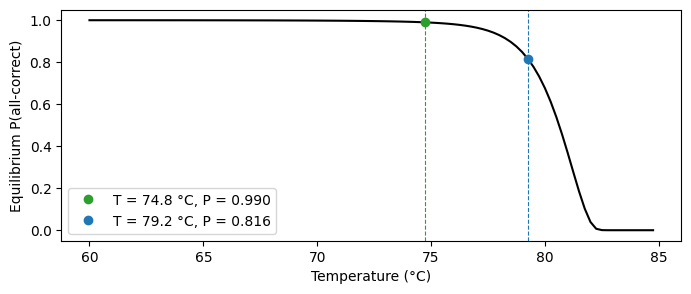

Low  temperature: T = 74.8 °C,  P(MFE) = 0.9898
High temperature: T = 79.2 °C,  P(MFE) = 0.8163


In [51]:
# Equilibrium probability of the all-correct configuration vs temperature.

params_cmp = make_bitcopy_params(N, input_bit="0", include_energies=True)
sys_sdc = SDC(params_cmp)

mfe_tiles_sdc, _ = sys_sdc.mfe_config()
mfe_names = [sys_sdc.tile_names[t] for t in mfe_tiles_sdc]
print(f"MFE (target) config: {mfe_names}")

# Scan temperatures
temps = np.arange(60, 85, 0.25)
eq_probs = []
for t in temps:
    sys_sdc.temperature = t
    eq_probs.append(sys_sdc.probability_of_state(mfe_tiles_sdc))
eq_probs = np.array(eq_probs)

# Pick two temperatures: one near the melting transition, one well below
T_high = temps[np.argmin(np.abs(eq_probs - 0.80))]
T_low  = temps[np.argmin(np.abs(eq_probs - 0.99))]
sys_sdc.temperature = T_high
p_high = sys_sdc.probability_of_state(mfe_tiles_sdc)
sys_sdc.temperature = T_low
p_low = sys_sdc.probability_of_state(mfe_tiles_sdc)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(temps, eq_probs, "k-")
for T, p, c in [(T_low, p_low, "C2"), (T_high, p_high, "C0")]:
    ax.axvline(T, color=c, ls="--", lw=0.8)
    ax.plot(T, p, "o", color=c, label=f"T = {T:.1f} \u00b0C, P = {p:.3f}")
ax.set_xlabel("Temperature (\u00b0C)")
ax.set_ylabel("Equilibrium P(all-correct)")
ax.legend()
plt.show()

print(f"Low  temperature: T = {T_low:.1f} \u00b0C,  P(MFE) = {p_low:.4f}")
print(f"High temperature: T = {T_high:.1f} \u00b0C,  P(MFE) = {p_high:.4f}")

In [ ]:
# Run five model configurations at two temperatures on k×N states.

K = 100
row_target = int(np.ceil(0.78 * K))
n_trials = 50
mfe_tiles_br = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]

# Build a second SDC system with a much stronger first scaffold domain.
# This keeps the input tile permanently bound, matching BR behavior.
params_strong_input = make_bitcopy_params(N, input_bit="0", include_energies=True)
params_strong_input.glue_dg_s["sc0"] = mean_energies(60)  # 3x longer domain
sys_sdc_strong = SDC(params_strong_input)


def count_correct_rows(canvas_view, mfe):
    arr = np.asarray(canvas_view)
    return int(np.all(arr == np.array(mfe)[np.newaxis, :], axis=1).sum())


def run_trials(sys, mfe, n_trials, K, max_time, is_br=False):
    times = []
    for _ in range(n_trials):
        st = State(
            (K, N),
            kind="SquareCompact",
            tracking="None",
            n_tile_types=len(sys.tile_names),
        )
        if is_br:
            sys.update_state(st)
        else:
            sys.update_all(st)
        event_batch = K * N
        while st.time < max_time:
            sys.evolve(st, for_events=event_batch)
            if count_correct_rows(st.canvas_view, mfe) >= row_target:
                break
        times.append(st.time)
    return np.array(times)


def make_br(params, T, bindunbind_replacement=False, allow_same=False):
    sys = SDC1DBindReplace(params)
    sys.account_for_energy = True
    sys.physical_attachment_rate = True
    sys.allow_weak_replacement = True
    sys.bindunbind_replacement_rate = bindunbind_replacement
    sys.allow_same_replacement = allow_same
    sys.set_param("temperature", T)
    return sys


results = {}
for label, T, p_eq in [("low", T_low, p_low), ("high", T_high, p_high)]:
    max_time = 5e6

    # Full SDC
    sys_sdc.temperature = T
    t_sdc = run_trials(sys_sdc, mfe_tiles_sdc, n_trials, K, max_time)

    # SDC with strong input domain
    sys_sdc_strong.temperature = T
    mfe_sdc_strong, _ = sys_sdc_strong.mfe_config()
    t_sdc_strong = run_trials(sys_sdc_strong, mfe_sdc_strong, n_trials, K, max_time)

    # BR: detachment-only replacement rate
    t_br = run_trials(
        make_br(params_cmp, T), mfe_tiles_br, n_trials, K, max_time, is_br=True
    )

    # BR: combined detach + attach replacement rate
    t_br2 = run_trials(
        make_br(params_cmp, T, bindunbind_replacement=True),
        mfe_tiles_br,
        n_trials,
        K,
        max_time,
        is_br=True,
    )

    # BR: combined detach + attach + allow same-tile replacement
    t_br3 = run_trials(
        make_br(params_cmp, T, bindunbind_replacement=True, allow_same=True),
        mfe_tiles_br,
        n_trials,
        K,
        max_time,
        is_br=True,
    )

    results[label] = dict(
        T=T,
        p_eq=p_eq,
        t_sdc=t_sdc,
        t_sdc_strong=t_sdc_strong,
        t_br=t_br,
        t_br2=t_br2,
        t_br3=t_br3,
    )

    print(f"T = {T:.1f} °C  (P_eq = {p_eq:.3f})")
    for name, t in [
        ("BR (detach only)", t_br),
        ("BR (detach + attach)", t_br2),
        ("BR (det + att + same)", t_br3),
        ("Full SDC", t_sdc),
        ("SDC (strong input)", t_sdc_strong),
    ]:
        ratio = np.median(t_sdc) / np.median(t) if np.median(t) > 0 else float("inf")
        print(f"  {name:26s}  median = {np.median(t):.2e} s  ({ratio:.1f}x vs SDC)")
    print()

In [ ]:
model_keys = [
    ("t_br", "C1", "BR (detach only)"),
    ("t_br2", "C2", "BR (detach + attach)"),
    ("t_br3", "C4", "BR (det + att + same)"),
    ("t_sdc", "C0", "Full SDC"),
    ("t_sdc_strong", "C9", "SDC (strong input)"),
]

fig, axes = plt.subplots(2, len(model_keys), figsize=(5 * len(model_keys), 8), sharey="row")

for row, label in enumerate(["low", "high"]):
    r = results[label]
    T, p_eq = r["T"], r["p_eq"]

    x_max = max(np.percentile(r[key], 99) for key, _, _ in model_keys)

    for col, (key, color, title) in enumerate(model_keys):
        t = r[key]
        axes[row, col].hist(
            t, bins=30, range=(0, x_max), color=color, alpha=0.7, edgecolor="k"
        )
        axes[row, col].axvline(
            np.median(t),
            color="C3",
            ls="--",
            label=f"median = {np.median(t):.2e} s",
        )
        axes[row, col].set_title(f"{title}\n(T = {T:.1f} \u00b0C, P = {p_eq:.2f})")
        axes[row, col].legend(fontsize=7)
        axes[row, col].set_xlim(0, x_max)
        if col == 0:
            axes[row, col].set_ylabel("Trials")

for col in range(len(model_keys)):
    axes[1, col].set_xlabel("Simulated time (s)")

fig.suptitle(
    f"Time for {row_target}/{K} rows to reach all-correct configuration",
    fontsize=14,
)
plt.tight_layout()
plt.show()

In [54]:
# Energy comparison: scaffold-strand bond energies
print("SDC scaffold energy bonds shape:", sys5.scaffold_energy_bonds.shape)
print("SDC strand energy bonds shape:", sys5.strand_energy_bonds.shape)
print("\nThe full SDC model computes the same bond energy matrices,")
print("but also accounts for scaffold concentration, detachment rates,")
print("and enables equilibrium calculations (mfe_config, partition_function).")

SDC scaffold energy bonds shape: (15, 33)
SDC strand energy bonds shape: (33, 33)

The full SDC model computes the same bond energy matrices,
but also accounts for scaffold concentration, detachment rates,
and enables equilibrium calculations (mfe_config, partition_function).
